---
title: Build Neural Network from Scratch using NumPy
author: Kunlei Lian
date: 06/24/2023
draft: false
categories:
  - Deep Learning
  - NumPy
jupyter: 'blog'
format:
  html:
    code-line-numbers: true
    code-overflow: wrap
    code-block-bg: true
    code-block-border-left: true
    highlight-style: Arrow
---

Neural networks are powerful mathematical models inspired by the structure of the human brain, capable of learning complex patterns from data. At their core, these models consist of layers of interconnected "neurons" which process input data and pass information forward through the network. The strength of these connections (called weights) are adjusted during training so that the network can make accurate predictions.

The process of updating these weights is accomplished through the backpropagation algorithm. Backpropagation enables the network to efficiently compute how much each weight contributes to the final prediction error, allowing the weights to be adjusted in the right direction to improve performance. This is done by propagating the error from the output layer backwards through the network, calculating gradients along the way.

In this blog post, we will break down the intuition behind neural networks and the backpropagation algorithm. Then, we will build a simple neural network from scratch using only NumPy, providing clear Python code to help you understand every step of the implementation.


## A Simple Neural Network

Let's take a look at a simple example neural network architecture. 
Below is a diagram of a feedforward neural network with three layers:

- **Input layer**: 6 neurons
- **Hidden layer**: 4 neurons
- **Output layer**: 3 neurons

Each neuron in one layer is fully connected to all neurons in the next layer. 
This architecture is typical for classification tasks where the input has six features and there are three possible output classes.

<img src="nn_example.png" alt="Neural Network with three layers: 6 input nodes, 4 hidden nodes, 3 output nodes" width="600">


Let's establish the key mathematical notations we will use throughout this neural network discussion:

- $w_{jk}^l$: the weight connecting the $k$th neuron in layer $(l-1)$ to the $j$th neuron in layer $l$
- $b_j^l$: the bias for the $j$th neuron in layer $l$
- $z_j^l$: the total weighted input to the $j$th neuron in layer $l$
- $a_j^l$: the activation (output) of the $j$th neuron in layer $l$
- $\sigma(z)$: the activation function (for example, the sigmoid function)
- $\delta_j^l$: the error or sensitivity of the $j$th neuron in layer $l$
- $C$: the cost (loss) function, which measures prediction error

These notations relate as follows:

- $z_j^l = \sum_k w_{jk}^l a_k^{l-1} + b_j^l$ &nbsp;&nbsp;&nbsp; (weighted input to neuron $j$)
- $a_j^l = \sigma(z_j^l)$ &nbsp;&nbsp;&nbsp; (activation for neuron $j$)
- $\delta_j^l = \dfrac{\partial C}{\partial z_j^l}$ &nbsp;&nbsp;&nbsp; (cost gradient with respect to $z_j^l$)

## Backpropagation Algorithm

The backpropagation algorithm is a systematic procedure for computing how the cost function $C$ depends on each weight and bias in a neural network. Using the notations introduced above, here is an overview of how backpropagation works:

1. **Forward Pass:** 
   - Starting from the input layer, pass the input $\mathbf{a}^0$ through the network.
   - At each neuron in layer $l$, compute the weighted input $z_j^l = \sum_k w_{jk}^l a_k^{l-1} + b_j^l$, and then its activation $a_j^l = \sigma(z_j^l)$.

2. **Calculate Output Error:** 
   - At the output layer $L$, compute the error $\delta_j^L$:
     $$
     \delta_j^L = \frac{\partial C}{\partial z_j^L}
     $$
   - With the chain rule, this is often written as:
     $$
     \delta_j^L = \frac{\partial C}{\partial a_j^L} \cdot \sigma'(z_j^L)
     $$

3. **Backpropagate the Error:** 
   - For each preceding layer $l = L-1, L-2, \ldots, 2$, compute the error term for layer $l$:
     $$
     \delta_j^l = \left( \sum_k w_{kj}^{l+1} \delta_k^{l+1} \right) \cdot \sigma'(z_j^l)
     $$
   - This equation expresses how errors in layer $l+1$ are propagated to layer $l$, modulated by the local derivative of the activation function.

4. **Compute Gradients:** 
   - The gradient of the cost with respect to each bias and weight can then be calculated as:
     $$
     \frac{\partial C}{\partial b_j^l} = \delta_j^l
     $$
     $$
     \frac{\partial C}{\partial w_{jk}^l} = a_k^{l-1} \delta_j^l
     $$

5. **Update Parameters:** 
   - Finally, the weights and biases are updated (for example, using gradient descent):
     $$
     w_{jk}^l \leftarrow w_{jk}^l - \eta \frac{\partial C}{\partial w_{jk}^l}
     $$
     $$
     b_j^l \leftarrow b_j^l - \eta \frac{\partial C}{\partial b_j^l}
     $$
   - Here, $\eta$ is the learning rate.

In summary, backpropagation efficiently computes how the cost function changes with respect to every weight and bias, enabling the neural network to learn by adjusting its parameters in a direction that reduces prediction error.




## Implementation with NumPy

Now let's translate the backpropagation algorithm into a working implementation using NumPy. This step-by-step implementation will allow us to build and train a simple neural network from scratch, following the logic we've just covered mathematically.

We'll define a NeuralNetwork class that allows for arbitrary network architectures by specifying the number of neurons in each layer. The code will include the initialization of weights and biases, the forward pass using the chosen activation function, and the backpropagation method for computing gradients. The backpropagation logic is integrated directly into the NeuralNetwork class, making it easier to use and more aligned with how modern deep learning frameworks work.

By leveraging NumPy arrays for all computations, we ensure efficient vectorized operations, which closely mimic the structure of equations we derived earlier. Let's look at the implementation details.




In [15]:
import numpy as np
import struct
import matplotlib.pyplot as plt
from typing import List, Dict, Callable
from array import array
from os.path  import join

rng = np.random.default_rng(seed=42)

In [16]:
def sigmoid(x):
  # Clamp x to prevent overflow
  x_clipped = np.clip(x, -500, 500)
  return 1.0 / (1 + np.exp(-x_clipped))

def sigmoid_prime(x):
  # Use the same clipping for consistency
  x_clipped = np.clip(x, -500, 500)
  s = sigmoid(x_clipped)
  return s * (1 - s)

In [17]:
class NeuralNetwork:
  def __init__(
    self,
    sizes: List[int],
    activation_func: Callable,
    activation_derivative: Callable,
    rng: np.random.Generator
  ):
    self.sizes = sizes
    self.num_layers = len(sizes)
    self.activation_func = activation_func
    self.activation_derivative = activation_derivative

    # Initialize weights and biases
    self.weights = [
      rng.normal(loc=0, scale=1, size=(y, x))
      for x, y in zip(sizes[:-1], sizes[1:])
    ]
    self.biases = [
      rng.normal(loc=0, scale=1, size=(y, 1))
      for y in sizes[1:]
    ]

    # Store pre-activations (z) and activations for each layer
    self.inputs = [np.zeros((y, 1)) for y in sizes[1:]]
    self.activations = [np.zeros((y, 1)) for y in sizes]

    # Initialize gradients and error terms for backpropagation
    self.delta = [np.zeros((y, 1)) for y in sizes[1:]]
    self.nabla_w = [
        np.zeros((y, x))
        for x, y in zip(sizes[:-1], sizes[1:])
    ]
    self.nabla_b = [
        np.zeros((y, 1))
        for y in sizes[1:]
    ]

  def forward(self, x):
    """Perform forward pass through the network."""
    self.activations[0][:] = x
    for layer in range(1, self.num_layers):
      z = self.weights[layer - 1] @ x + self.biases[layer - 1]
      self.inputs[layer - 1][:] = z
      a = self.activation_func(z)
      self.activations[layer][:] = a
      x = a

  def backward(self, y):
    """
    Compute gradients using backpropagation algorithm.
    Assumes the network has already performed a forward pass.
    
    Args:
      y: Target output (one-hot encoded)
    """
    # Output layer error: dC/da * activation'
    output_activation = self.activations[-1]
    self.delta[-1][:] = (output_activation - y) * self.activation_derivative(self.inputs[-1])

    # Propagate error backwards through the network
    for l in range(2, self.num_layers):
      sp = self.activation_derivative(self.inputs[-l])
      w_next = self.weights[-l + 1]
      delta_next = self.delta[-l + 1]
      self.delta[-l][:] = sp * (w_next.T @ delta_next)

    # Compute gradients for weights and biases
    # nabla_b: gradient for biases is just the error term (delta)
    for l in range(len(self.delta)):
      self.nabla_b[l][:] = self.delta[l]

    # nabla_w: gradient for weights is delta @ activation.T from previous layer
    for l in range(1, self.num_layers):
      self.nabla_w[-l][:] = self.delta[-l] @ self.activations[-l - 1].T

  def get_gradients(self):
    """
    Return the computed gradients for weights and biases.
    Useful for external optimizers or custom update rules.
    """
    return self.nabla_w, self.nabla_b


The `NeuralNetwork` class includes a `backward()` method that implements the backpropagation algorithm. This method is responsible for computing the gradients of the neural network's weights and biases, which is a crucial step in training. After a forward pass is performed, `backward()` computes the "error" at each layer (how much each neuron's output contributed to the prediction mistake), and then determines how each weight and bias should be adjusted to reduce the overall error.

The backpropagation method works as follows:

- **`backward(y)`**: After a forward pass, this method calculates the error (delta) at each layer, starting from the output layer and propagating backwards. It then computes the gradients for weights (`nabla_w`) and biases (`nabla_b`) for each layer. The gradients are stored in the network object and can be accessed via `get_gradients()` if needed.

By integrating backpropagation directly into the NeuralNetwork class, we create a more cohesive and intuitive API that aligns with modern deep learning frameworks like PyTorch and TensorFlow.



## Handwritten Digits Recognization

Now that we have implemented a neural network from scratch, let's put it to the test by applying it to a real-world problem: recognizing handwritten digits. We'll use the famous **MNIST dataset**, which consists of 70,000 grayscale images of handwritten digits (0-9), each of size 28×28 pixels. This is a classic benchmark problem in machine learning and provides an excellent opportunity to see our neural network in action.

**What this section demonstrates:**

1. **Data Loading and Preprocessing**: We'll load the MNIST dataset and transform the images into a format suitable for our neural network (flattening 28×28 images into 784-dimensional vectors and converting labels to one-hot encoded format).

2. **Network Architecture**: We'll construct a neural network with 784 input neurons (one for each pixel), a hidden layer with 100 neurons, and 10 output neurons (one for each digit class). This architecture allows the network to learn complex patterns in the pixel data.

3. **Training Process**: We'll train the network using stochastic gradient descent with mini-batches, monitoring both training and testing performance to track learning progress and detect potential overfitting.

4. **Performance Analysis**: After training, we'll conduct a comprehensive evaluation including:
   - **Loss and accuracy curves** to visualize learning progress over time
   - **Confusion matrix** to identify which digits are commonly confused
   - **Per-class accuracy** to see performance breakdown by digit
   - **Sample predictions** to visually inspect correct and incorrect classifications
   - **Overfitting analysis** by comparing training vs. testing performance
   - **Prediction confidence distribution** to understand the model's certainty

This practical application will demonstrate how the mathematical concepts and implementation we developed earlier work together to solve a real classification problem, giving you insight into both the strengths and limitations of a simple neural network architecture.


### Data Preparation

The following class, MnistDataloader, is a utility to load the MNIST digit dataset from files in IDX format (the raw format distributed by Yann LeCun's website). It reads image and label binary files directly, parsing the format according to the MNIST specification. The class provides a method to load both training and test data, returning images as 2D numpy arrays and labels as integer arrays. This enables us to work with the dataset for training and evaluating our neural network without relying on external libraries.



In [18]:
# https://www.kaggle.com/code/hojjatk/read-mnist-dataset?scriptVersionId=9466282&cellId=1

class MnistDataloader(object):
  def __init__(self, training_images_filepath,training_labels_filepath,
                test_images_filepath, test_labels_filepath):
    self.training_images_filepath = training_images_filepath
    self.training_labels_filepath = training_labels_filepath
    self.test_images_filepath = test_images_filepath
    self.test_labels_filepath = test_labels_filepath
  
  def read_images_labels(self, images_filepath, labels_filepath):        
    labels = []
    with open(labels_filepath, 'rb') as file:
      magic, size = struct.unpack(">II", file.read(8))
      if magic != 2049:
          raise ValueError('Magic number mismatch, expected 2049, got {}'.format(magic))
      labels = array("B", file.read())        
    
    with open(images_filepath, 'rb') as file:
      magic, size, rows, cols = struct.unpack(">IIII", file.read(16))
      if magic != 2051:
          raise ValueError('Magic number mismatch, expected 2051, got {}'.format(magic))
      image_data = array("B", file.read())        
    images = []
    for i in range(size):
      images.append([0] * rows * cols)
    for i in range(size):
      img = np.array(image_data[i * rows * cols:(i + 1) * rows * cols])
      img = img.reshape(28, 28)
      images[i][:] = img            
    
    return images, labels
          
  def load_data(self):
    x_train, y_train = self.read_images_labels(self.training_images_filepath, self.training_labels_filepath)
    x_test, y_test = self.read_images_labels(self.test_images_filepath, self.test_labels_filepath)
    return (x_train, y_train),(x_test, y_test)    

Let's visualize a few examples from the loaded MNIST dataset that will be used for neural network training.

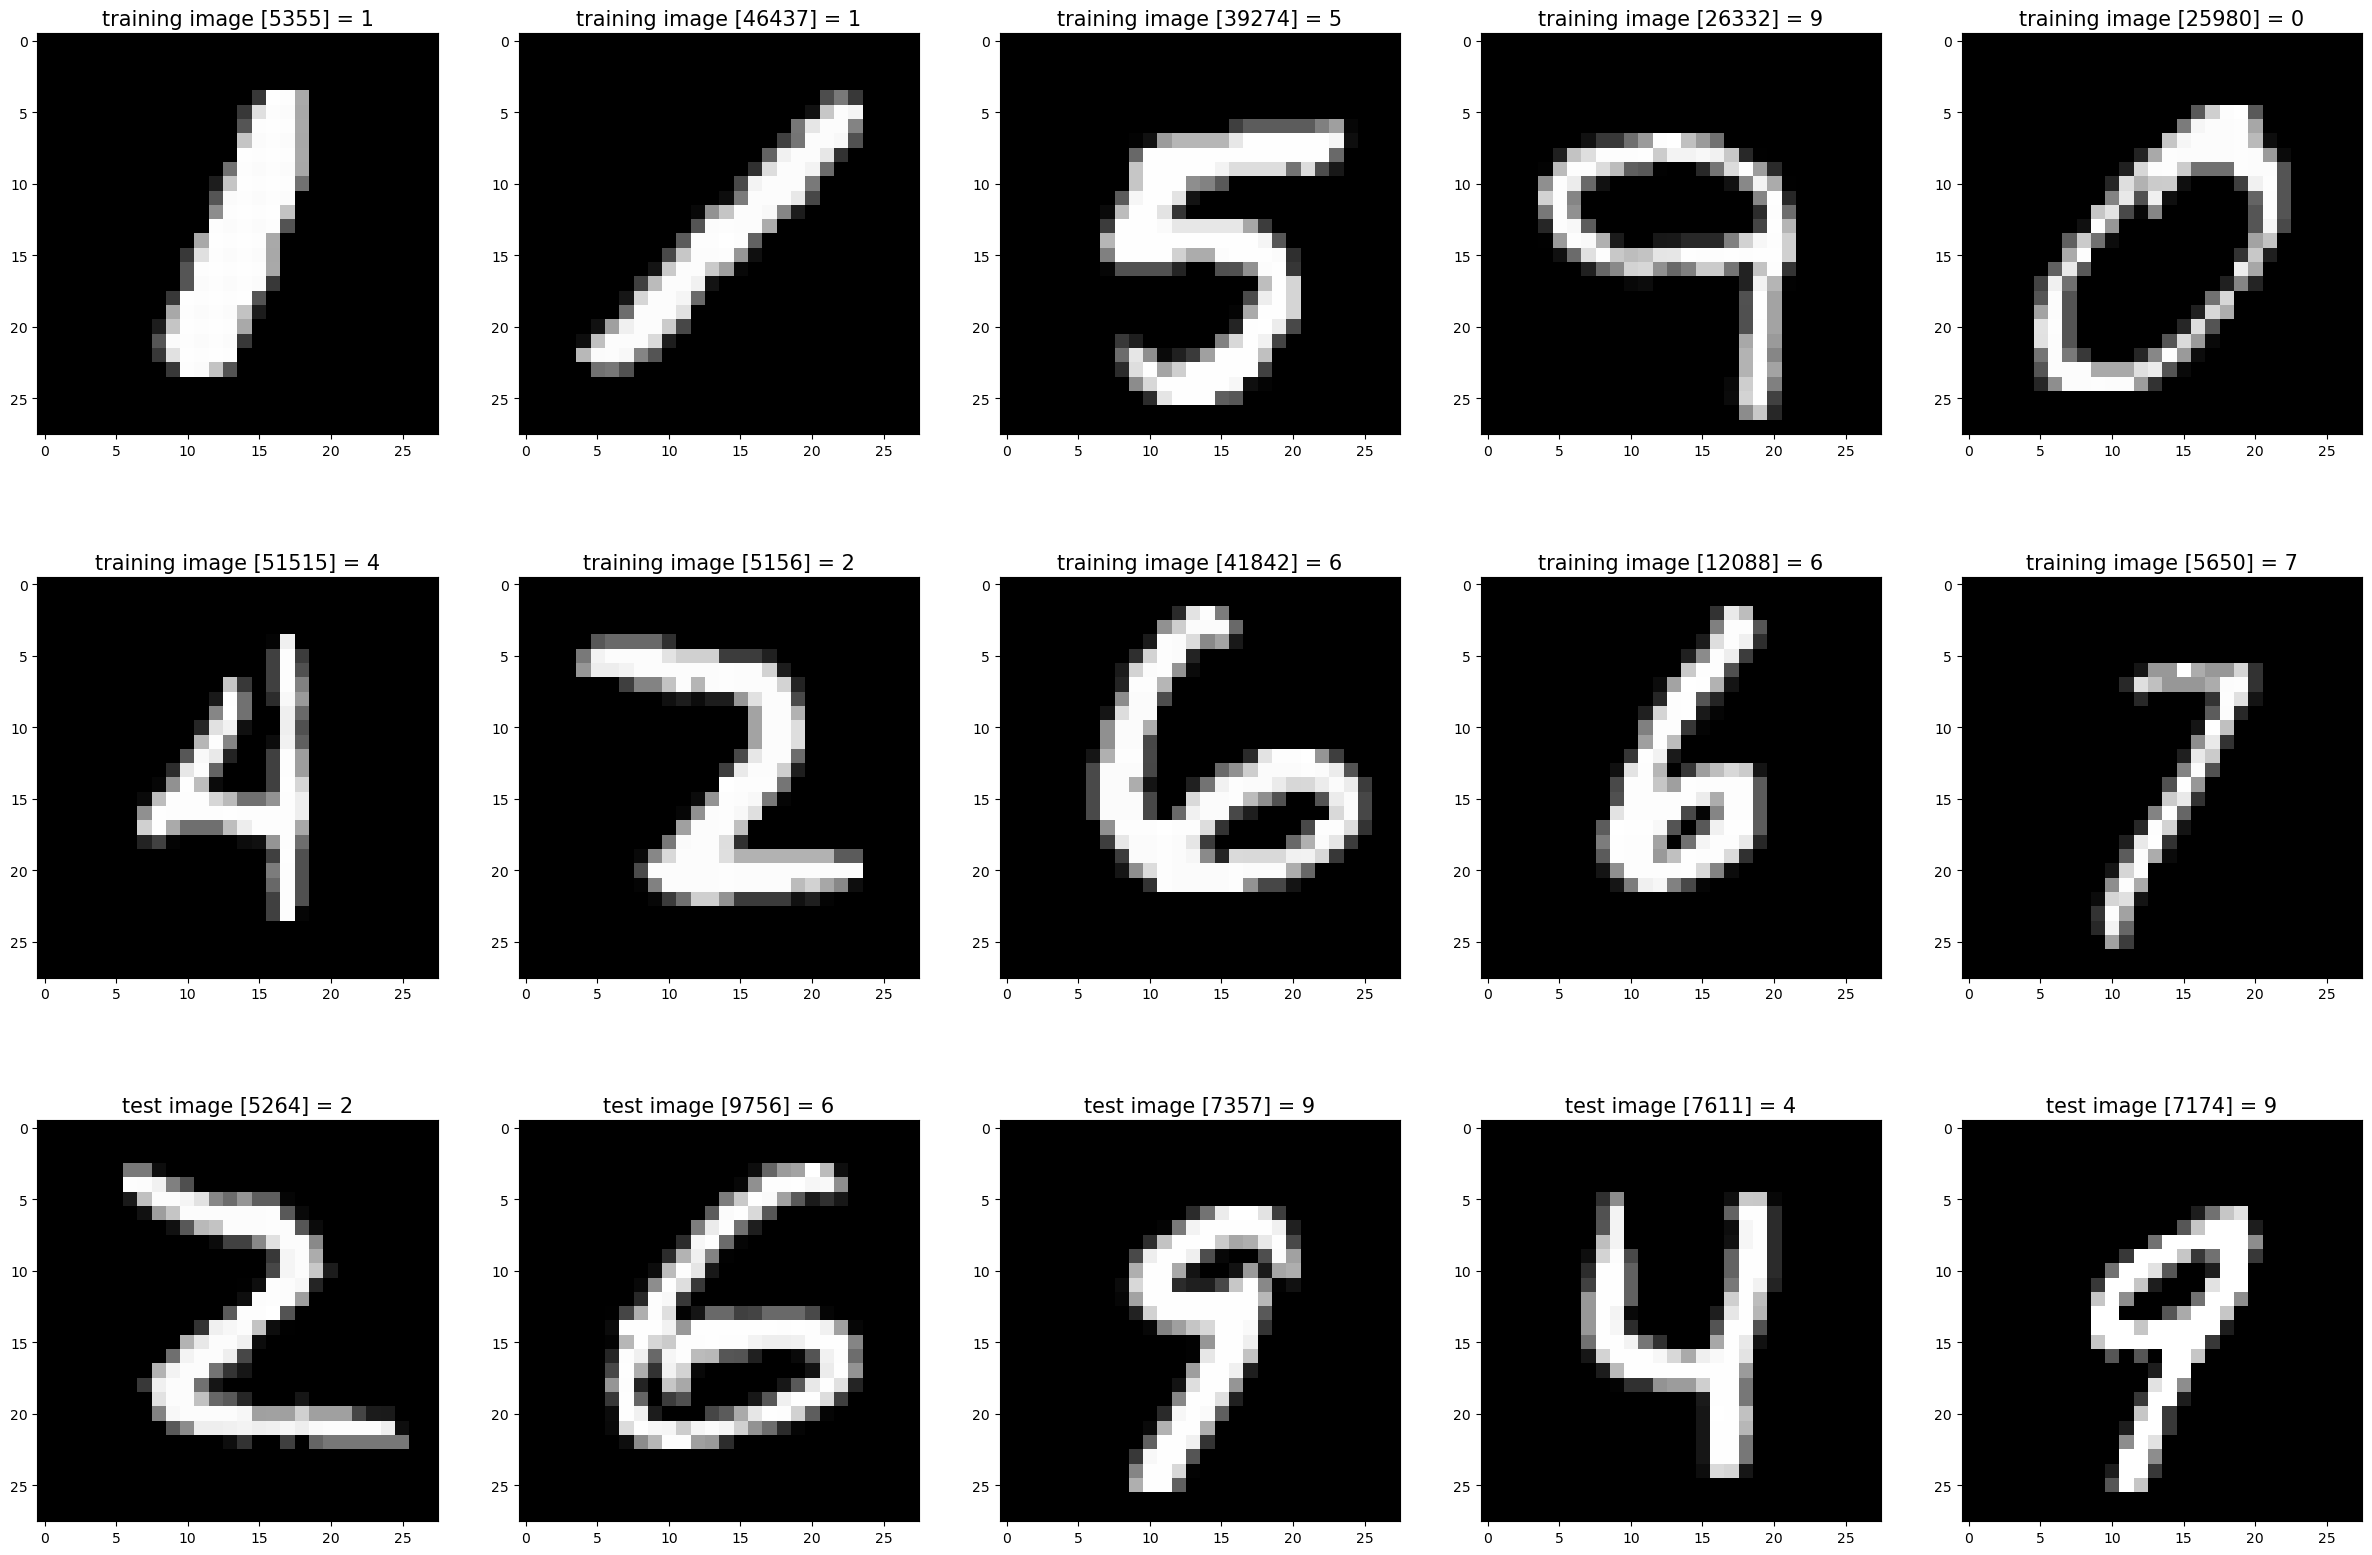

In [19]:
%matplotlib inline

# Set file paths for the MNIST dataset
input_path = '/Users/klian/dev/deep-learning/datasets/mnist/full'
training_images_filepath = join(input_path, 'train-images-idx3-ubyte/train-images-idx3-ubyte')
training_labels_filepath = join(input_path, 'train-labels-idx1-ubyte/train-labels-idx1-ubyte')
test_images_filepath = join(input_path, 't10k-images-idx3-ubyte/t10k-images-idx3-ubyte')
test_labels_filepath = join(input_path, 't10k-labels-idx1-ubyte/t10k-labels-idx1-ubyte')

# Helper function to display a list of images with their corresponding titles
def show_images(images, title_texts):
  cols = 5
  rows = (len(images) + cols - 1) // cols
  plt.figure(figsize=(30, 20))
  for idx, (image, title_text) in enumerate(zip(images, title_texts), 1):
    plt.subplot(rows, cols, idx)
    plt.imshow(image, cmap=plt.cm.gray)
    if title_text:
      plt.title(title_text, fontsize=15)

# Load the MNIST dataset
mnist_dataloader = MnistDataloader(
  training_images_filepath, training_labels_filepath,
  test_images_filepath, test_labels_filepath
)
(x_train_orig, y_train_orig), (x_test_orig, y_test_orig) = mnist_dataloader.load_data()

# Display some random training and test images
images_2_show = []
titles_2_show = []

for _ in range(10):
  r = rng.integers(0, 60000)
  images_2_show.append(x_train_orig[r])
  titles_2_show.append(f'training image [{r}] = {y_train_orig[r]}')

for _ in range(5):
  r = rng.integers(0, 10000)
  images_2_show.append(x_test_orig[r])
  titles_2_show.append(f'test image [{r}] = {y_test_orig[r]}')

show_images(images_2_show, titles_2_show)

### 

### Training

In [20]:
def transform(x, y):
  x_trans = np.array(x).reshape(-1, 784, 1)

  y_trans = np.zeros((len(y), 10, 1))
  for idx, label in enumerate(y):
    y_trans[idx, label, 0] = 1
  
  return x_trans, y_trans

In [21]:
x_train, y_train = transform(x_train_orig, y_train_orig)
x_test, y_test = transform(x_test_orig, y_test_orig)

In [22]:
def mean_squared_error(y_true, y_pred):
  """
  Calculate mean squared error loss.
  """
  return np.mean((y_true - y_pred) ** 2)

def calculate_loss_and_accuracy(network, x_data, y_data):
  total_loss, total_correct = 0.0, 0
  num_samples = len(x_data)

  for x, y in zip(x_data, y_data):
    network.forward(x)
    y_pred = network.activations[-1]

    loss = mean_squared_error(y, y_pred)
    total_loss += loss

    predicted_class = np.argmax(y_pred)
    actual_class = np.argmax(y)
    if predicted_class == actual_class:
      total_correct += 1
  
  return total_loss / num_samples, total_correct / num_samples

def get_predictions(network, x_data):
  """
  Get predictions for a dataset.
  """
  predictions = []
  for x in x_data:
    network.forward(x)
    y_pred = network.activations[-1]
    predictions.append(np.argmax(y_pred))
  return np.array(predictions)


def get_actual_labels(y_data):
  """
  Get actual labels from one-hot encoded data.
  """
  return np.array([np.argmax(y) for y in y_data])


In [23]:
# Enhanced training loop with accuracy tracking
epochs = 50
batch_size = 32
learning_rate = 0.1

network = NeuralNetwork(
    sizes=[784, 100, 10], 
    activation_func=sigmoid, 
    activation_derivative=sigmoid_prime,
    rng=rng
)

# Lists to store metrics
train_losses = []
test_losses = []
train_accuracies = []
test_accuracies = []

for epoch in range(epochs):
  # Shuffle x_train and y_train in unison
  permutation = rng.permutation(len(x_train))
  x_train = x_train[permutation]
  y_train = y_train[permutation]

  # train the model in batches
  num_batches = len(x_train) // batch_size
  for i in range(num_batches):
    start = i * batch_size
    end = start + batch_size
    x_batch = x_train[start:end]
    y_batch = y_train[start:end]

    nabla_w = [np.zeros((y, x)) for x, y in zip(network.sizes[:-1], network.sizes[1:])]
    nabla_b = [np.zeros((y, 1)) for y in network.sizes[1:]]
    for x, y in zip(x_batch, y_batch):
      network.forward(x)
      network.backward(y)

      for idx, w in enumerate(network.nabla_w):
        nabla_w[idx] += w
      
      for idx, b in enumerate(network.nabla_b):
        nabla_b[idx] += b
    
    # update the weights and biases
    for idx, w in enumerate(nabla_w):
      network.weights[idx] -= learning_rate * w / batch_size
    
    for idx, b in enumerate(nabla_b):
      network.biases[idx] -= learning_rate * b / batch_size

  if epoch % 5 == 0:
    # Evaluate metrics after each epoch
    train_loss, train_acc = calculate_loss_and_accuracy(network, x_train, y_train)
    test_loss, test_acc = calculate_loss_and_accuracy(network, x_test, y_test)
    
    train_losses.append(train_loss)
    test_losses.append(test_loss)
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)
    
    print(f"Epoch {epoch + 1}/{epochs}: Train Loss = {train_loss:.4f}, Test Loss = {test_loss:.4f}, Train Acc = {train_acc:.4f}, Test Acc = {test_acc:.4f}")

print(f"\nFinal Metrics:")
print(f"Training Loss: {train_losses[-1]:.4f}, Training Accuracy: {train_accuracies[-1]:.4f}")
print(f"Testing Loss: {test_losses[-1]:.4f}, Testing Accuracy: {test_accuracies[-1]:.4f}")


Epoch 1/50: Train Loss = 0.0920, Test Loss = 0.0915, Train Acc = 0.2611, Test Acc = 0.2647
Epoch 6/50: Train Loss = 0.0626, Test Loss = 0.0622, Train Acc = 0.5041, Test Acc = 0.5030
Epoch 11/50: Train Loss = 0.0539, Test Loss = 0.0537, Train Acc = 0.5788, Test Acc = 0.5826
Epoch 16/50: Train Loss = 0.0490, Test Loss = 0.0485, Train Acc = 0.6098, Test Acc = 0.6130
Epoch 21/50: Train Loss = 0.0471, Test Loss = 0.0469, Train Acc = 0.6216, Test Acc = 0.6222
Epoch 26/50: Train Loss = 0.0447, Test Loss = 0.0446, Train Acc = 0.6351, Test Acc = 0.6346
Epoch 31/50: Train Loss = 0.0438, Test Loss = 0.0441, Train Acc = 0.6381, Test Acc = 0.6379
Epoch 36/50: Train Loss = 0.0431, Test Loss = 0.0432, Train Acc = 0.6431, Test Acc = 0.6443
Epoch 41/50: Train Loss = 0.0425, Test Loss = 0.0426, Train Acc = 0.6474, Test Acc = 0.6454
Epoch 46/50: Train Loss = 0.0416, Test Loss = 0.0419, Train Acc = 0.6549, Test Acc = 0.6492

Final Metrics:
Training Loss: 0.0416, Training Accuracy: 0.6549
Testing Loss: 0.0

## Performance Validation

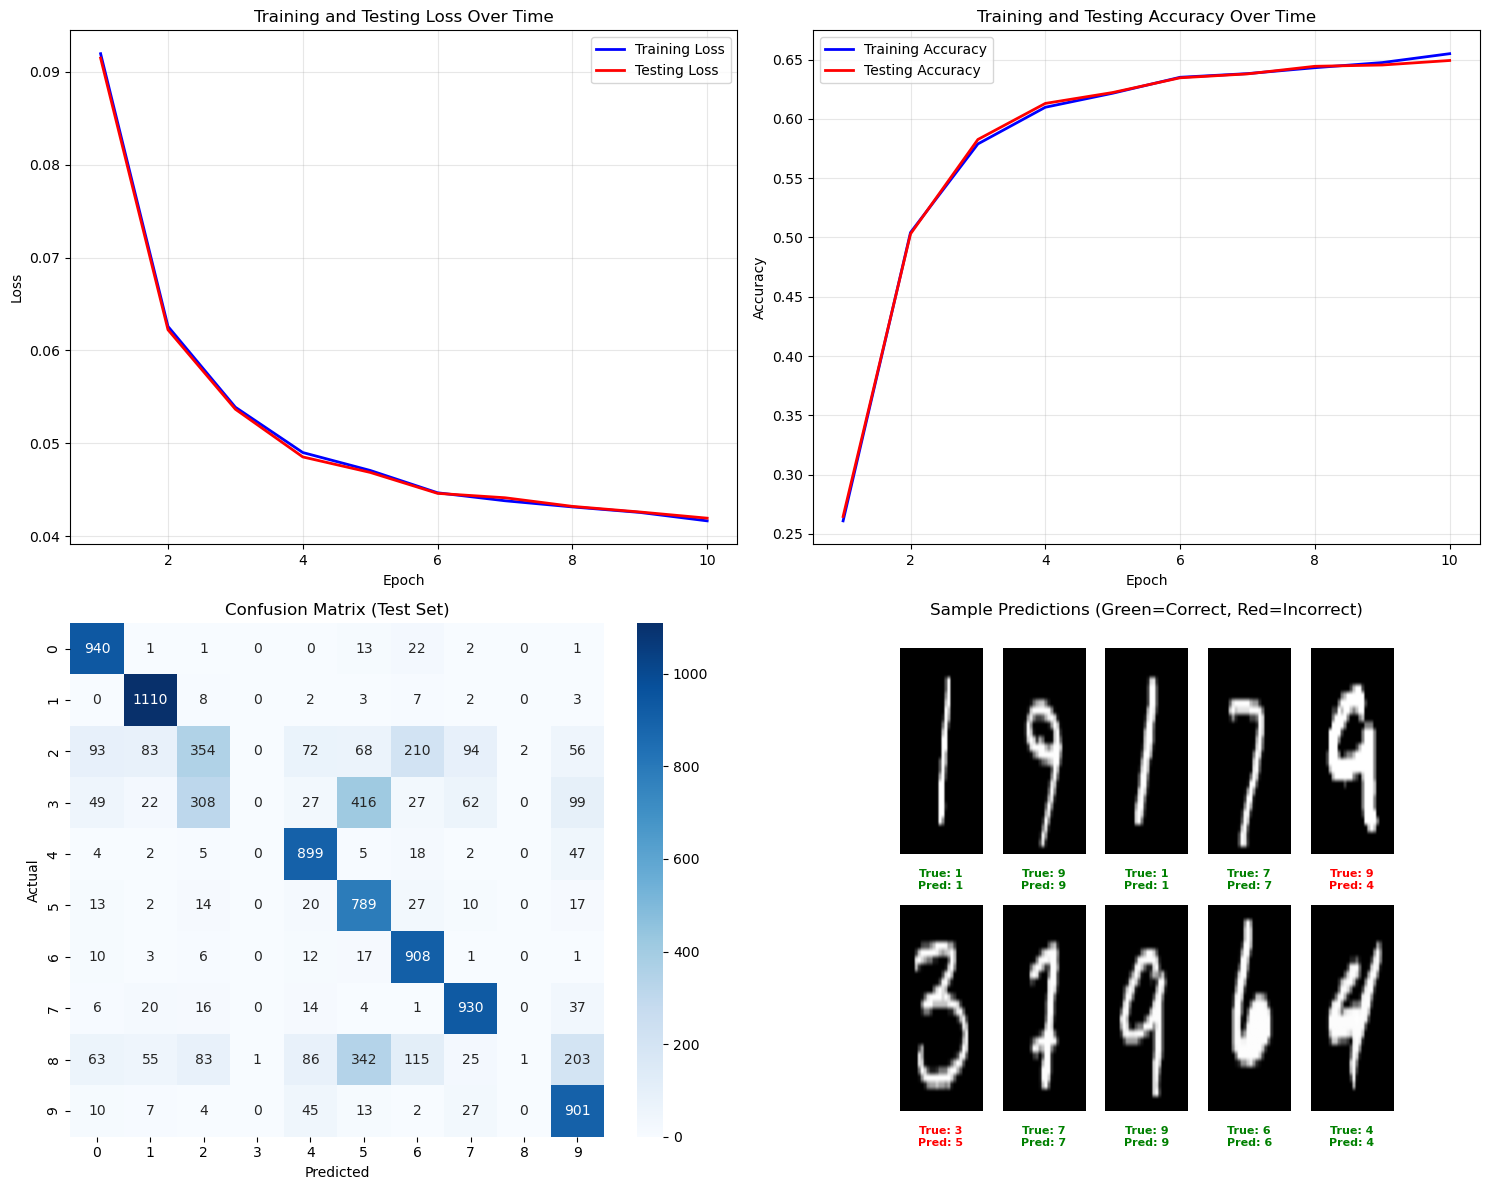

In [24]:
# Comprehensive visualization plots
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Loss curves
axes[0, 0].plot(range(1, len(train_losses) + 1), train_losses, 'b-', label='Training Loss', linewidth=2)
axes[0, 0].plot(range(1, len(train_losses) + 1), test_losses, 'r-', label='Testing Loss', linewidth=2)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Training and Testing Loss Over Time')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Accuracy curves
axes[0, 1].plot(range(1, len(train_losses) + 1), train_accuracies, 'b-', label='Training Accuracy', linewidth=2)
axes[0, 1].plot(range(1, len(train_losses) + 1), test_accuracies, 'r-', label='Testing Accuracy', linewidth=2)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].set_title('Training and Testing Accuracy Over Time')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Get predictions on test set
test_predictions = get_predictions(network, x_test)
test_actual = get_actual_labels(y_test)

cm = confusion_matrix(test_actual, test_predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1, 0])
axes[1, 0].set_xlabel('Predicted')
axes[1, 0].set_ylabel('Actual')
axes[1, 0].set_title('Confusion Matrix (Test Set)')

# 4. Sample predictions visualization
# Show some sample predictions
sample_indices = rng.choice(len(x_test), size=10, replace=False)
sample_images = [x_test_orig[int(idx)] for idx in sample_indices]
sample_actual = [y_test_orig[int(idx)] for idx in sample_indices]
sample_predictions = test_predictions[sample_indices]

# Create a grid of sample predictions
cols = 5
rows = 2
axes[1, 1].axis('off')
for idx, (img, actual, pred) in enumerate(zip(sample_images, sample_actual, sample_predictions)):
    row = idx // cols
    col = idx % cols
    y_pos = 1 - (row * 0.5) - 0.25
    x_pos = col * 0.2 + 0.1
    
    # Display image
    axes[1, 1].imshow(img, cmap='gray', extent=[x_pos-0.08, x_pos+0.08, y_pos-0.2, y_pos+0.2])
    
    # Add prediction text
    color = 'green' if actual == pred else 'red'
    axes[1, 1].text(x_pos, y_pos-0.25, f'True: {actual}\nPred: {pred}', 
                    ha='center', va='center', fontsize=8, color=color, weight='bold')

axes[1, 1].set_xlim(0, 1)
axes[1, 1].set_ylim(0, 1)
axes[1, 1].set_title('Sample Predictions (Green=Correct, Red=Incorrect)')

plt.tight_layout()
plt.show()


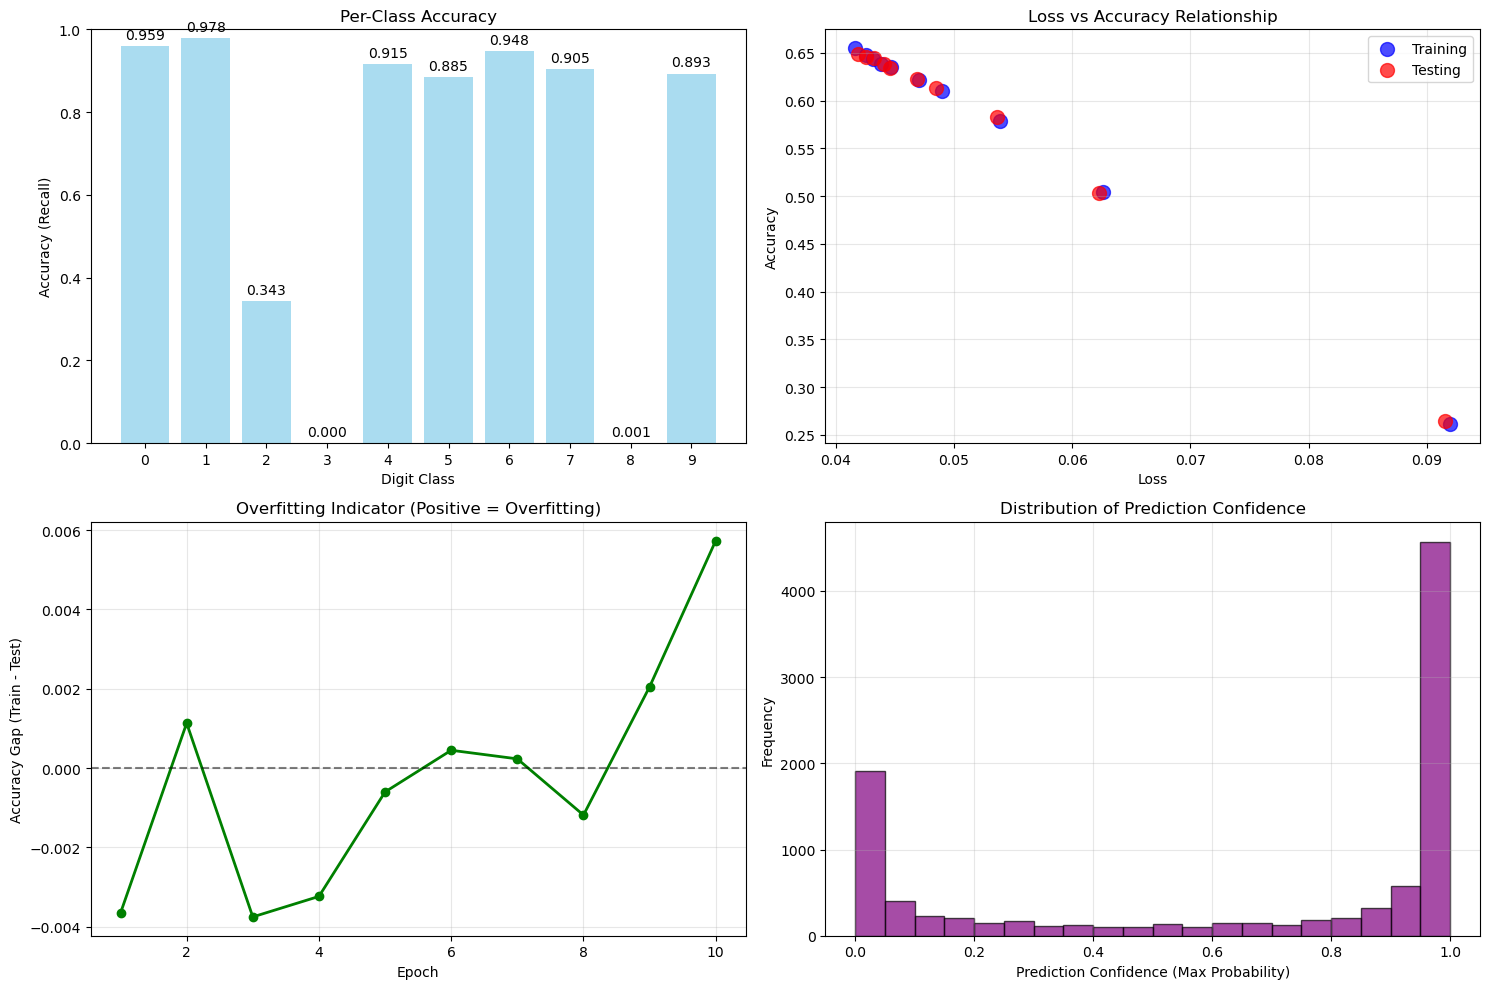

In [ ]:
# Additional analysis plots
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Per-class accuracy
from sklearn.metrics import classification_report
class_report = classification_report(
    test_actual, test_predictions, output_dict=True, zero_division=0
)
class_names = [str(i) for i in range(10)]
class_accuracies = [class_report[str(i)]['recall'] for i in range(10)]

axes[0, 0].bar(class_names, class_accuracies, color='skyblue', alpha=0.7)
axes[0, 0].set_xlabel('Digit Class')
axes[0, 0].set_ylabel('Accuracy (Recall)')
axes[0, 0].set_title('Per-Class Accuracy')
axes[0, 0].set_ylim(0, 1)
for i, v in enumerate(class_accuracies):
    axes[0, 0].text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom')

# 2. Loss vs Accuracy scatter
axes[0, 1].scatter(train_losses, train_accuracies, color='blue', alpha=0.7, label='Training', s=100)
axes[0, 1].scatter(test_losses, test_accuracies, color='red', alpha=0.7, label='Testing', s=100)
axes[0, 1].set_xlabel('Loss')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].set_title('Loss vs Accuracy Relationship')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Learning curve (accuracy gap)
accuracy_gap = [t_acc - test_acc for t_acc, test_acc in zip(train_accuracies, test_accuracies)]
axes[1, 0].plot(range(1, len(train_losses) + 1), accuracy_gap, 'g-', linewidth=2, marker='o')
axes[1, 0].axhline(y=0, color='black', linestyle='--', alpha=0.5)
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Accuracy Gap (Train - Test)')
axes[1, 0].set_title('Overfitting Indicator (Positive = Overfitting)')
axes[1, 0].grid(True, alpha=0.3)

# 4. Prediction confidence distribution
# Get prediction probabilities for test set
test_probabilities = []
for x in x_test:
    network.forward(x)
    y_pred = network.activations[-1]
    max_prob = np.max(y_pred)
    test_probabilities.append(max_prob)

axes[1, 1].hist(test_probabilities, bins=20, alpha=0.7, color='purple', edgecolor='black')
axes[1, 1].set_xlabel('Prediction Confidence (Max Probability)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Distribution of Prediction Confidence')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [27]:
# Comprehensive performance summary
print("=" * 60)
print("NEURAL NETWORK PERFORMANCE SUMMARY")
print("=" * 60)

print(f"\nFINAL METRICS:")
print(f"   Training Loss: {train_losses[-1]:.4f}")
print(f"   Testing Loss:  {test_losses[-1]:.4f}")
print(f"   Training Accuracy: {train_accuracies[-1]:.4f} ({train_accuracies[-1]*100:.2f}%)")
print(f"   Testing Accuracy:  {test_accuracies[-1]:.4f} ({test_accuracies[-1]*100:.2f}%)")

print(f"\nIMPROVEMENT:")
print(f"   Loss Reduction: {((train_losses[0] - train_losses[-1]) / train_losses[0] * 100):.2f}%")
print(f"   Accuracy Improvement: {((train_accuracies[-1] - train_accuracies[0]) * 100):.2f}%")

print(f"\nOVERFITTING ANALYSIS:")
final_gap = train_accuracies[-1] - test_accuracies[-1]
if final_gap > 0.05:
    print(f"   Potential overfitting detected (gap: {final_gap:.3f})")
elif final_gap < -0.02:
    print(f"   Good generalization (gap: {final_gap:.3f})")
else:
    print(f"   Balanced performance (gap: {final_gap:.3f})")

print(f"\nCLASSIFICATION REPORT:")
print(classification_report(test_actual, test_predictions, digits=3))

print(f"\nCONFUSION MATRIX SUMMARY:")
cm = confusion_matrix(test_actual, test_predictions)
print(f"   Total predictions: {cm.sum()}")
print(f"   Correct predictions: {np.trace(cm)}")
print(f"   Incorrect predictions: {cm.sum() - np.trace(cm)}")

print("=" * 60)


NEURAL NETWORK PERFORMANCE SUMMARY

FINAL METRICS:
   Training Loss: 0.0416
   Testing Loss:  0.0419
   Training Accuracy: 0.6549 (65.49%)
   Testing Accuracy:  0.6492 (64.92%)

IMPROVEMENT:
   Loss Reduction: 54.73%
   Accuracy Improvement: 39.39%

OVERFITTING ANALYSIS:
   Balanced performance (gap: 0.006)

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

           0      0.791     0.959     0.867       980
           1      0.851     0.978     0.910      1135
           2      0.443     0.343     0.387      1032
           3      0.000     0.000     0.000      1010
           4      0.764     0.915     0.833       982
           5      0.472     0.885     0.616       892
           6      0.679     0.948     0.791       958
           7      0.805     0.905     0.852      1028
           8      0.333     0.001     0.002       974
           9      0.660     0.893     0.759      1009

    accuracy                          0.683     10000
   macro avg     